# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Data

In [3]:
version = "2026-05-15-15h"
df_filepath = f"/gpfs01/berens/data/data/Eyewire2/manuscript/df_all_neurons_{version}.pickle"
df = pd.read_pickle(df_filepath)
print(df.shape)

(59003, 400)


In [4]:
df = df[(df.cellclass_final=='AC')].copy()

In [5]:
assert not df.columns.duplicated().any()

# Labels and subset

In [59]:
celltype2short = {
    'DAC': '',
    'Bowtie deep in IPL': 'Bowtie',
    'Wide-field mid IPL': 'WF-mid', 
    'nNOS-2': '', 
    'Midnight': 'MN',
    #'Wide-field ON non-spiny sparse', 
    #'Separate dendrites and axons',
    'A1': '', 
    #'Wide-field ON non-spiny dense',
    #'Wide-field ON spiny spikelets', 
    #'Wide-field ON spiny spikes',
    'Comet': '',
    #'Medium-field dorsal pointing low in IPL': 'MF-dp-low',
    'ON SAC': '',
    'vGlut3': '',
    'A2': '',
    'H20': '',
    'H22': '',
    'H13': '',
    'H14': '',
    'H18': '',
    'H23': '',
    'H19': '',
    'H15': '',
    'H21': '',
    'H42': '',
    'H46': '',
    'H35': '',
    'H36': '',
    'Medium-field deep in IPL sustained': 'sMF-deep',
    'Medium-field deep in IPL transient': 'tMF-deep',
    'PAC': '',
    'VIP1 (VIPm)': '',
    #'Medium-field low in IPL sustained': 'sMF-low',
    #'Medium-field low in IPL transient': 'tMF-low',
    'H52': '',
    'Medium-field Mid-IPL smooth': 'MF-mid-s',
    'Medium-field Mid-IPL varicose': 'MF-mid-v',
    'OFF SAC': '',
    'A17 large': '',
    'A17 small': '',
}

celltype2short = {n: s if len(s) > 0 else n for n, s in celltype2short.items()}
celltype2short

{'DAC': 'DAC',
 'Bowtie deep in IPL': 'Bowtie',
 'Wide-field mid IPL': 'WF-mid',
 'nNOS-2': 'nNOS-2',
 'Midnight': 'MN',
 'A1': 'A1',
 'Comet': 'Comet',
 'ON SAC': 'ON SAC',
 'vGlut3': 'vGlut3',
 'A2': 'A2',
 'H20': 'H20',
 'H22': 'H22',
 'H13': 'H13',
 'H14': 'H14',
 'H18': 'H18',
 'H23': 'H23',
 'H19': 'H19',
 'H15': 'H15',
 'H21': 'H21',
 'H42': 'H42',
 'H46': 'H46',
 'H35': 'H35',
 'H36': 'H36',
 'Medium-field deep in IPL sustained': 'sMF-deep',
 'Medium-field deep in IPL transient': 'tMF-deep',
 'PAC': 'PAC',
 'VIP1 (VIPm)': 'VIP1 (VIPm)',
 'H52': 'H52',
 'Medium-field Mid-IPL smooth': 'MF-mid-s',
 'Medium-field Mid-IPL varicose': 'MF-mid-v',
 'OFF SAC': 'OFF SAC',
 'A17 large': 'A17 large',
 'A17 small': 'A17 small'}

In [60]:
#df_subset = pd.read_csv('AC types for Figure.csv')

In [61]:
celltype2show = {ct: ct in celltype2short.keys() for ct in df['celltype'].unique()}
celltype2show

{None: False,
 'H23': True,
 'ON SAC': True,
 'H22': True,
 'H36': True,
 'H13': True,
 'Separate dendrites and axons': False,
 'A2': True,
 'Other': False,
 'nNOS-2': True,
 'Medium-field Mid-IPL smooth': True,
 'A1': True,
 'Bowtie deep in IPL': True,
 'H19': True,
 'Comet': True,
 'H46': True,
 'H20': True,
 'A17 large': True,
 'Wide-field mid IPL': True,
 'Midnight': True,
 'H15': True,
 'vGlut3': True,
 'H35': True,
 'H18': True,
 'Wide-field ON spiny spikelets': False,
 'OFF SAC': True,
 'H14': True,
 'H52': True,
 'Medium-field low in IPL transient': False,
 'EW5to': False,
 'Medium-field low in IPL sustained': False,
 'H42': True,
 'A17 small': True,
 'Medium-field deep in IPL transient': True,
 'H21': True,
 'DAC': True,
 'VIP1 (VIPm)': True,
 'PAC': True,
 'Wide-field ON spiny spikes': False,
 'Wide-field ON non-spiny dense': False,
 'Medium-field Mid-IPL varicose': True,
 'Unknown': False,
 'PixON': False,
 'OFF vertical OS - asymmetric': False,
 'Wide-field ON non-spiny spa

In [62]:
df['celltype_short'] = df['celltype'].apply(lambda x: celltype2short.get(x, None))
df['celltype_final_short'] = df['celltype_final'].apply(lambda x: celltype2short.get(x, None))
df['valid_celltype_final_short'] = df['celltype_final'].apply(lambda x: celltype2show.get(x, False))

### Collect labels

In [63]:
unique_labels = np.sort(np.unique(df.loc[df["valid_celltype_final_short"], "celltype_final"]))
unique_labels_short = np.sort(np.unique(df.loc[df["valid_celltype_final_short"], "celltype_final_short"]))

In [64]:
print(len(unique_labels), len(unique_labels_short))

33 33


In [65]:
unique_labels_short

array(['A1', 'A17 large', 'A17 small', 'A2', 'Bowtie', 'Comet', 'DAC',
       'H13', 'H14', 'H15', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23',
       'H35', 'H36', 'H42', 'H46', 'H52', 'MF-mid-s', 'MF-mid-v', 'MN',
       'OFF SAC', 'ON SAC', 'PAC', 'VIP1 (VIPm)', 'WF-mid', 'nNOS-2',
       'sMF-deep', 'tMF-deep', 'vGlut3'], dtype=object)

In [66]:
df.shape

(13419, 406)

## TSNE

In [67]:
emb_cols_norm = [c for c in df.columns if c.startswith('AC-RGCemb_norm')]
emb_cols_norm

['AC-RGCemb_norm-r-PC0',
 'AC-RGCemb_norm-r-PC1',
 'AC-RGCemb_norm-r-PC2',
 'AC-RGCemb_norm-r-PC3',
 'AC-RGCemb_norm-t-PC0',
 'AC-RGCemb_norm-t-PC1',
 'AC-RGCemb_norm-z-PC0',
 'AC-RGCemb_norm-z-PC1',
 'AC-RGCemb_norm-z-PC2',
 'AC-RGCemb_norm-z-PC3',
 'AC-RGCemb_norm-z-PC4',
 'AC-RGCemb_norm-z-PC5',
 'AC-RGCemb_norm-z-PC6',
 'AC-RGCemb_norm-z-PC7',
 'AC-RGCemb_norm-z-PC8',
 'AC-RGCemb_norm-z-PC9',
 'AC-RGCemb_norm-z-PC10',
 'AC-RGCemb_norm-z-PC11',
 'AC-RGCemb_norm-res(rt)-PC0',
 'AC-RGCemb_norm-res(rz)-PC0',
 'AC-RGCemb_norm-res(rz)-PC1',
 'AC-RGCemb_norm-res(rz)-PC2',
 'AC-RGCemb_norm-res(tz)-PC0',
 'AC-RGCemb_norm-soma_z_um',
 'AC-RGCemb_norm-log_xys_dens_mean',
 'AC-RGCemb_norm-log_hull_diameter',
 'AC-RGCemb_norm-log_hull_perimeter',
 'AC-RGCemb_norm-log_tips',
 'AC-RGCemb_norm-log_branch_points',
 'AC-RGCemb_norm-log_median_intermediate_segment_pl',
 'AC-RGCemb_norm-log_median_terminal_segment_pl',
 'AC-RGCemb_norm-log_tortuosity_median',
 'AC-RGCemb_norm-branch_angle_median',
 'A

In [68]:
emb_feats_norm = df[emb_cols_norm].values
emb_feats_norm.shape

(13419, 47)

In [16]:
df['include_in_embedding'] = (df.cellclass_final=='AC') & df["valid_cellclass_final"]

In [17]:
import scanpy as sc

adata = sc.AnnData(df.loc[df['include_in_embedding'], emb_cols_norm].values)
sc.tl.tsne(adata, perplexity=8, use_rep='X', random_state=0)  # 20?

In [18]:
df['tsne_d0'] = np.nan
df['tsne_d1'] = np.nan

df.loc[df["include_in_embedding"], 'tsne_d0'] = adata.obsm["X_tsne"][:, 0]
df.loc[df["include_in_embedding"], 'tsne_d1'] = adata.obsm["X_tsne"][:, 1]

## Prepare mosaic cell types

In [19]:
celltypes_to_mosaic = ["A2", "H22", "ON SAC", "OFF SAC", "DAC", "MN"]

A2 []
H22 []
ON SAC []
OFF SAC []
DAC []
MN []


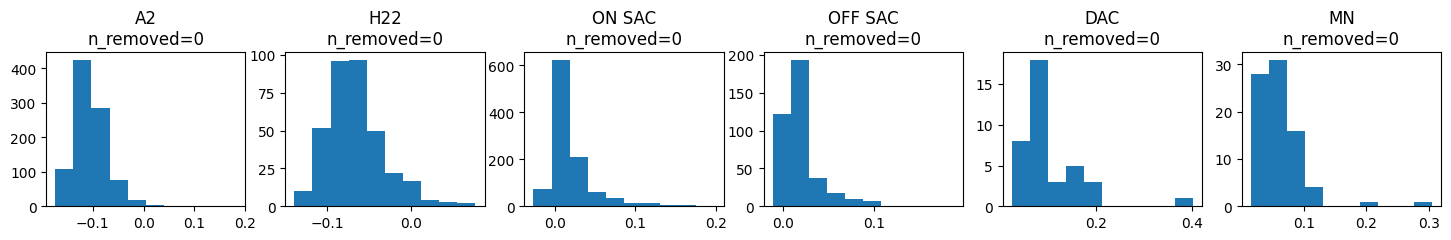

In [20]:
# Some cells still have their axon unlabeled, let's remove them here for the mosaics
df_mosaics = df[df["valid_celltype_final_short"]].copy()
df_mosaics["hull_shape_idx"] = ((df.hull_perimeter + 10) / (df.hull_diameter + 10)) / np.pi - 1

fig, axs = plt.subplots(1, len(celltypes_to_mosaic), figsize=(len(celltypes_to_mosaic)*3, 2))

check_cells = []

for i, ct in enumerate(celltypes_to_mosaic):
    df_ct = df_mosaics[(df_mosaics.celltype_final_short == ct)]

    df_ct_flag = df_ct[df_ct["hull_shape_idx"] > 0.5]
    
    print(ct, list(df_ct_flag.index))
    check_cells += list(df_ct_flag.index)

    ax = axs[i]
    ax.set_title(f"{ct}\nn_removed={len(df_ct_flag)}")
    ax.hist(df_ct.hull_shape_idx)

# Confirm the selection manually before filtering
rm_cells = check_cells
df_mosaics = df_mosaics.loc[~df_mosaics.index.isin(rm_cells)]

## Get one per type

In [69]:
size_order = df[df.valid_celltype_final_short].groupby('celltype_final_short').aggregate(
    {'hull_diameter': 'mean'}).sort_values('hull_diameter').index.values

all_types_rows = []

for celltype_final_short in size_order:
    if celltype_final_short not in celltypes_to_mosaic:  # OPTIONAL
        continue
    
    rows = df[(df.celltype_final_short == celltype_final_short)
        & df.valid_celltype_final_short]

    if sum(rows.celltype_final_decision == 'both_strong') > 0:
        rows = rows[rows.celltype_final_decision == 'both_strong']
    
    if len(rows) == 0:
        rows = None
        print(celltype_final_short)

    if rows is None:
        row = None
    else:
        x = rows['tsne_d0']
        y = rows['tsne_d1']
        
        emb_ct = np.stack([x, y]).T
        
        ct_mean = np.mean(emb_ct, axis=0)
        ct_dists = np.sum((emb_ct - ct_mean) ** 2, axis=1) ** 0.5
        row = rows.iloc[np.argmin(ct_dists)]
        
    all_types_rows.append(row)
    
all_types_rows = pd.DataFrame(all_types_rows)
all_types_rows.head(2)

,ew,post_has_cal,post_has_axon,polar_dens_id_1,polar_dens_id_2,z_dens_id_1,row,link,nuc,status,...,ALLemb_norm-log_radius_median,ALLemb_norm-log_radius_std,ALLemb_norm-log_radius_q5,ALLemb_norm-log_radius_q95,celltype_final_short,valid_celltype_final_short,include_in_embedding,tsne_d0,tsne_d1,log_soma_rad_um
720575940567739723,2,1,0,1,2.0,1,F10943,https://spelunker.cave-explorer.org/#!middleau...,720575940563143265,Complete,...,-0.486993,0.116225,-0.588567,-0.100132,A2,True,True,-27.987192,85.136520,1.899052
720575940582105406,2,1,0,1,2.0,1,F11693,https://spelunker.cave-explorer.org/#!middleau...,720575940545378441,Complete,...,-1.618944,-0.312722,-1.979632,-0.730047,H22,True,True,-75.618317,-50.481956,1.606542


In [70]:
for i, name in all_types_rows['celltype_final'].items():
    print(i, name)

720575940567739723 A2
720575940582105406 H22
720575940565743726 ON SAC
720575940547977603 OFF SAC
720575940550286119 DAC
720575940563874843 Midnight


# Figures

In [23]:
from eyewire2_morphological_clustering.utils.style import set_rc_params

set_rc_params()

In [24]:
fig_dir = f'../figures/AC/v{version}'
os.makedirs(fig_dir, exist_ok=True)

## Feature plots

### Dendrograms

In [72]:
from eyewire2_morphological_clustering.utils.dendrogram import ClusterDendrogram

cd = ClusterDendrogram(
    data=emb_feats_norm[df.valid_celltype_final_short & df.include_in_embedding],
    cluster_labels=df.loc[df.valid_celltype_final_short & df.include_in_embedding, "celltype_final_short"],
    feature_names=emb_cols_norm,
)
avg_features = cd.compute_cluster_averages(log_transform=False)
filtered_features, selected_features = cd.filter_features(verbose=False)
dist_matrix = cd.compute_distance_matrix(metric='euclidean')
Z = cd.hierarchical_cluster(method='average')

In [73]:
# import warnings
# from eyewire2_morphological_clustering.utils.dendrogram import PairwiseDiscriminability

# pair_ds = PairwiseDiscriminability(regularization='ledoit_wolf')
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     dend = pair_ds.fit(emb_feats_norm[df.valid_celltype_final_short], df.loc[df.valid_celltype_final_short, "celltype_final_short"])

In [74]:
from scipy.cluster.hierarchy import dendrogram, linkage

dendro = dendrogram(
    cd.Z,
    labels=cd.clusters,
    leaf_font_size=8,
    color_threshold=0,
    above_threshold_color='gray',
    no_plot=True,
)

In [75]:
leaf_order = cd.clusters[dendro['leaves']]
leaf_order

array(['DAC', 'A1', 'MN', 'Bowtie', 'WF-mid', 'nNOS-2', 'Comet', 'ON SAC',
       'sMF-deep', 'tMF-deep', 'vGlut3', 'A2', 'H20', 'H22', 'H13', 'H14',
       'H18', 'H23', 'H19', 'H15', 'H21', 'H42', 'H46', 'H35', 'H36',
       'PAC', 'VIP1 (VIPm)', 'H52', 'MF-mid-s', 'MF-mid-v', 'OFF SAC',
       'A17 large', 'A17 small'], dtype=object)

In [76]:
len(unique_labels)

33

In [77]:
len(leaf_order)

33

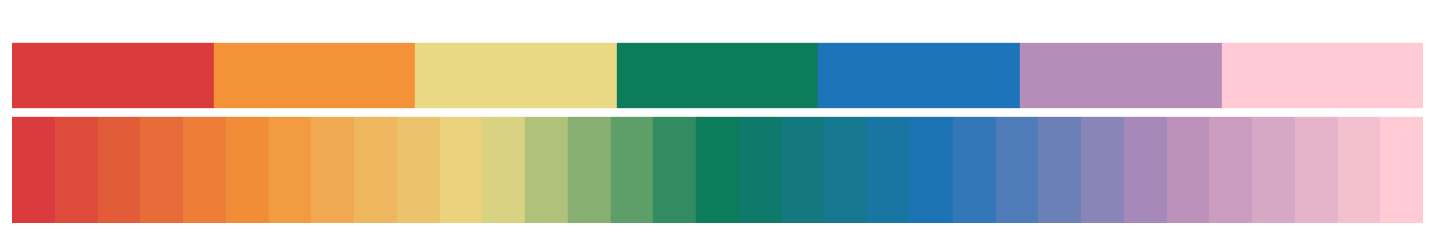

In [78]:
from eyewire2_morphological_clustering.utils import colors

interpolated_colors = colors.interpolate_colors(n=len(unique_labels))
ordered_colors = colors.reorder_colors_for_distinction(interpolated_colors, n_neighbors=4)

label2color = {leaf_name: ordered_colors[i] for i, leaf_name in enumerate(leaf_order)}

### Plot stats

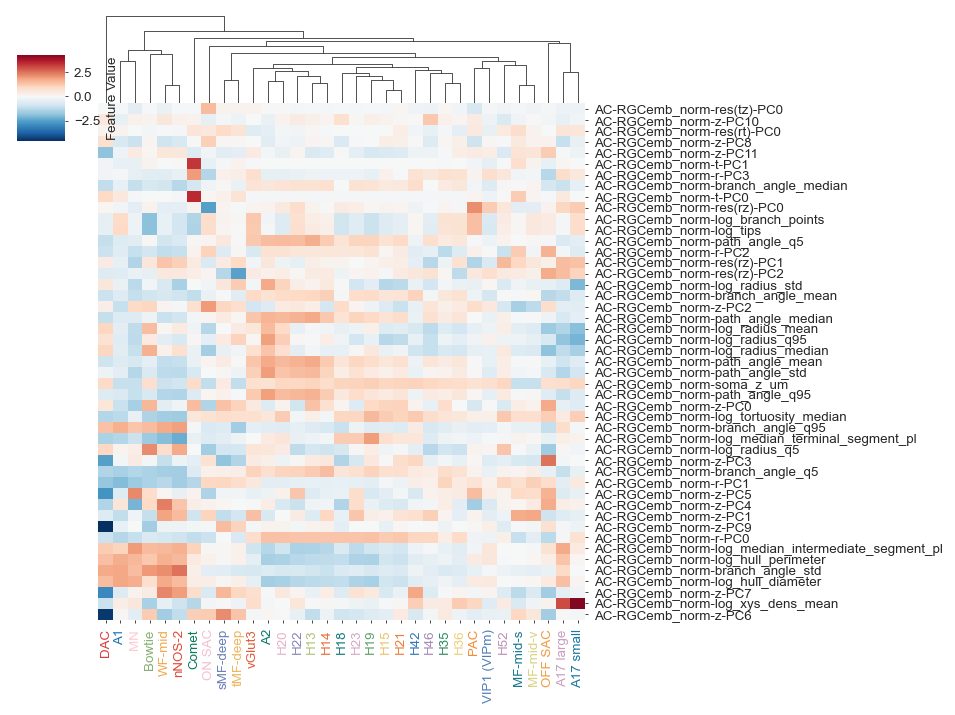

In [79]:
fig = cd.plot_heatmap_with_dendrogram(top_n_features=50, figsize=(8, 6))

ax = fig.ax_heatmap
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.tick_params("x", rotation=90)
xlabels = ax.get_xmajorticklabels()
xlabelnames = []
for label in xlabels:
    label.set_color(label2color[label.get_text()])

fig.savefig(f'{fig_dir}/AC-dendrogram_features.svg')
fig.savefig(f'{fig_dir}/AC-dendrogram_features.png', dpi=600)
plt.show()

### Plot dendrogram

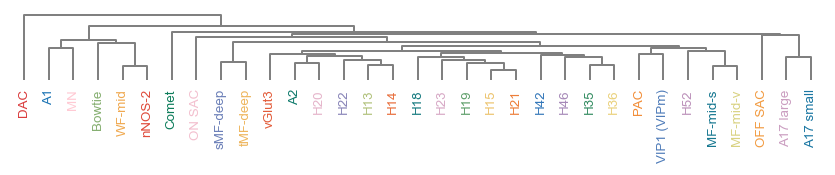

In [80]:
fig, ax = plt.subplots(figsize=(7, 1.5))
sns.despine(left=True, bottom=True, right=True, top=True)

# Plot dendrogram
dendro = dendrogram(
    cd.Z,
    labels=cd.clusters,
    ax=ax,
    leaf_font_size=8,
    color_threshold=0,
    above_threshold_color='gray',
    no_plot=False,
)

ax.tick_params("x", rotation=90)
xlabels = ax.get_xmajorticklabels()
xlabelnames = []
for label in xlabels:
    label.set_color(label2color[label.get_text()])

assert len(np.unique(xlabelnames)) == len(xlabelnames)

ax.set_yticks([])
plt.tight_layout()

fig.savefig(f'{fig_dir}/AC-dendrogram.svg')
fig.savefig(f'{fig_dir}/AC-dendrogram.png', dpi=600)
plt.show()

## TSNE

### Plot

/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/embedding.py:229: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


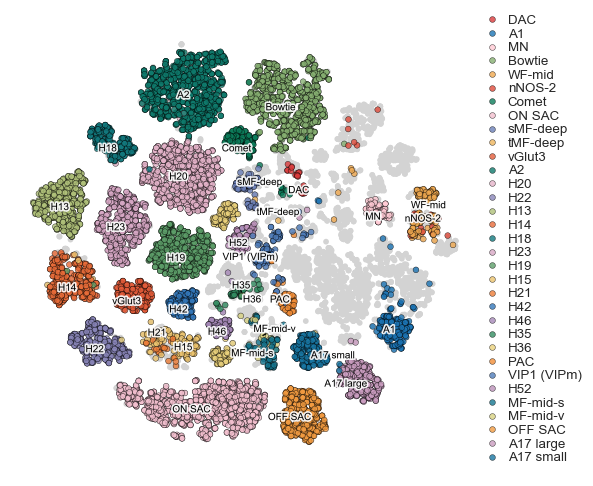

In [88]:
from eyewire2_morphological_clustering.utils.embedding import plot_embedding_v2

plot_embedding_v2(
    df=df[df['include_in_embedding']],
    label2color=label2color,
    fig_path_prefix=f"{fig_dir}/AC-tsne",
    celltype_col="celltype_final_short",
    plot_order=leaf_order,
    is_labelled_col="valid_celltype_final_short",
    dot_size=12,
    edgecolor="k",
    rasterized=False,
    legend_markerscale=None,
    figsize=(5, 5),
)

### Feature maps

In [82]:
df.rename({"perc_z_095_1": "perc_z_095", "perc_z_005_1": "perc_z_005"}, axis=1, inplace=True)

In [83]:
df["log_soma_rad_um"] = np.log(df["soma_rad_um"])

In [84]:
example_feature_names = [
    'perc_z_005',
    'perc_z_095',

    'log_hull_diameter',
    'log_branch_points',
    
    'log_radius_mean',
]

example_features = df.loc[:, example_feature_names].values

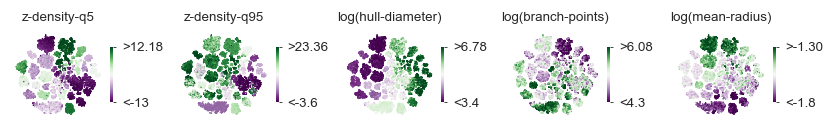

In [85]:
from eyewire2_morphological_clustering.utils.embedding import save_and_plot_feats

fig, axs = save_and_plot_feats(
    all_emb=df.loc[df['include_in_embedding'], ['tsne_d0', 'tsne_d1']].values,
    all_feats=example_features[df['include_in_embedding']],
    all_feat_names=example_feature_names, 
    ncols=len(example_feature_names),
    fig_dir=fig_dir,
    file_prefix="AC-tnse-features",
    clip=False,
    stride=1, 
    s=0.6,
    figsize_per_cell=(1.4, 1.4)
)

## Morph examples

/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


0
[720575940567739723, 720575940582105406]


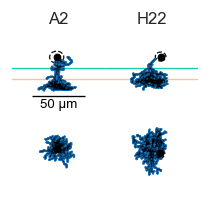

1
[720575940565743726, 720575940547977603]


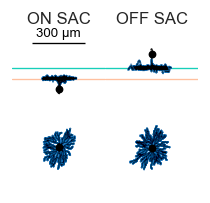

2
[720575940550286119, 720575940563874843]


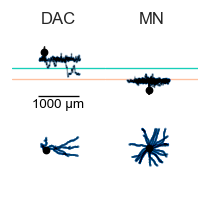

In [86]:
from eyewire2_morphological_clustering.utils.plot_cells import plot_rows

nrows = 3
splits = np.array_split(all_types_rows, nrows)

for i in range(nrows):
    rows = splits[i]

    print(i)
    print(list(rows.index.astype(int)))
    
    fig, axs = plt.subplots(
        2, len(rows), figsize=(min(7, rows.shape[0]), 1.7),
        sharex='all', sharey='row', squeeze=False, height_ratios=(1, 1.2),
        subplot_kw=dict(xlabel=None, ylabel=None, xticks=[], yticks=[]))
    fig.subplots_adjust(wspace=0, hspace=0)

    rad = rows.hull_diameter.max() * 1.1
    size = int(np.ceil(rows.hull_diameter.max() * 1.1 / 50)) * 50

    if size > 500:
        size = int(size / 500) * 500
    elif size > 150:
        size = int(size / 100) * 100
    
    plot_rows(
        rows=rows,
        rad=rad, size=size,
        fig=fig, axs=axs,
        color=colors.cellclass2color['AC'],
        show_on_tsne=False, sb_fontsize=8);

    for ax in axs.flat:
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.axis('off')
    
    for j, ax in enumerate(axs[0, :]):
        ct_short = rows.iloc[j].celltype_final_short

        ax.set_title(f"{ct_short}")
        
        # df_ct = df[(df.celltype_final_short==ct_short) & df.valid_celltype_final]
        # n_cells = len(df_ct)
        # n_cells_clf = sum(df_ct.celltype_final_decision == 'classifier')
        # n_cells_label = n_cells - n_cells_clf

        # if n_cells_clf > 0:
        #     ax.set_title(f"{ct_short}\n(n={n_cells_label} [+{n_cells_clf}])", fontsize=7)
        # else:
        #     ax.set_title(f"{ct_short}\n(n={n_cells_label})", fontsize=7)

    fig.savefig(f'{fig_dir}/celltype_final-example_set{i}.svg', dpi=600, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/celltype_final-example_set{i}.png', dpi=600, bbox_inches='tight')
    
    plt.show()

## Mosaics

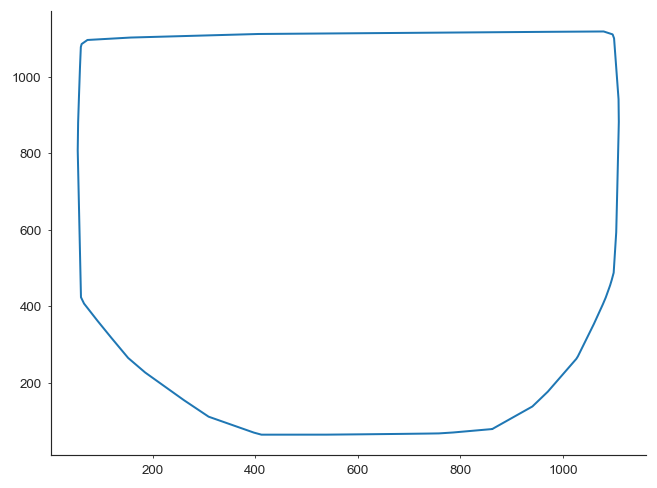

In [40]:
from scipy.spatial import ConvexHull

pts = np.vstack(df.hull_points)[:, :2]
hull = ConvexHull(pts)

# Get hull boundary points in order, closed
hull_pts = pts[np.append(hull.vertices, hull.vertices[0])]
plt.plot(*hull_pts.T)
plt.show()

celltype='A2': Found 555 cells and 361 candidates.
celltype='H22': Found 233 cells and 120 candidates.
celltype='ON SAC': Found 852 cells and 190 candidates.
celltype='OFF SAC': Found 337 cells and 53 candidates.
celltype='DAC': Found 11 cells and 27 candidates.
celltype='MN': Found 42 cells and 39 candidates.


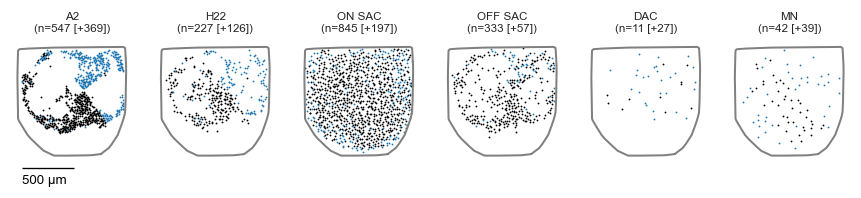

In [41]:
from eyewire2_morphological_clustering.utils.mosaics import plot_multiple_mosaics

max_val = 7

celltypes = celltypes_to_mosaic
marker_sizes = [1.2] * len(celltypes)
ncols = len(celltypes)

for name, extent in {'wide': [50, 1150, 50, 1150]}.items(): # 'zoom2': [200, 300, 600, 700], 'zoom': [200, 400, 600, 800]
    
    fig, axs = plt.subplots(ncols=len(celltypes), nrows=1, figsize=(len(celltypes)*1.5, 2),
                            sharex='row', sharey='row', squeeze=False)    
    if 'wide' in name.lower():
        sns.despine(top=True, right=True, left=True, bottom=True)
    else:
        sns.despine(top=False, right=False, left=False, bottom=False)
    
    ims, c_maxs = plot_multiple_mosaics(
        df=df[df.valid_celltype_final_short],
        celltype_col='celltype_short',
        candidate_col='celltype_final_short',
        candidate_color='C0',
        celltypes=celltypes,
        fig=fig,
        coverage_axs=None,
        resolutions=[1000] * ncols,
        center_axs=axs[0, :],            
        title_axs=axs[0, :],
        sb_axs=[axs[0, 0]],
        center_x_col="soma_x_um",
        center_y_col="soma_y_um",
        marker_sizes=marker_sizes,
        max_val=max_val,
        extent=extent,
        plot_outlines='zoom' in name.lower(),
        outline_hull=hull_pts if 'wide' in name.lower() else None,
        cb=False,
        sb_size=500 if 'wide' in name.lower() else 100,
        outline_kws = dict(c='gray', ls='-', clip_on=False),
    )

    for j, ax in enumerate(axs.flat):
        celltype = celltypes[j]
        df_ct = df[(df.celltype_final_short==celltype) & df.valid_celltype_final_short]
        n_cells = len(df_ct)
        n_cells_clf = sum(df_ct.celltype_final_decision == 'classifier')
        n_cells_label = n_cells - n_cells_clf
        if n_cells_clf > 0:
            ax.set_title(f"{celltype}\n(n={n_cells_label} [+{n_cells_clf}])", fontsize=7)
        else:
            ax.set_title(f"{celltype}\n(n={n_cells_label})", fontsize=7)
    
    fig.savefig(f'{fig_dir}/scatter-class_{extent}.svg', dpi=600, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/scatter-class_{extent}.png', dpi=600, bbox_inches='tight')
    plt.show()